# Universidad de Buenos Aires
# Aprendizaje Profundo - TP2
# Cohorte 19 - 2do bimestre 2025
# OJEDA, Juan Cruz


Este segundo TP se debe entregar hasta las **23hs del jueves 19 de junio (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar los contenidos vistos en clase y otra bibliografía. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP2 EQUIVALE AL 40% DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Permitir acceso a gvilcamiza.ext@fi.uba.ar y habilitar los comentarios, para poder darles el feedback. El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/xbkD2HvthW89Wiuj7)**. Tanto los resultados, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

NO ES NECESARIO QUE NOS ENVIEN COREEO AVISANDO DE LA ENTREGA.

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP2.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP2-Co19.ipynb**
- Los códigos deben poder ejecutarse.
- Los resultados, cómo el código, los gráficos y las explicaciones deben quedar guardados y visualizables en el correspondiente notebook.

# **CLASIFICADOR DE EMOCIONES**

El objetivo de este trabajo es construir una red neuronal convolucional (CNN) utilizando Pytorch, capaz de clasificar emociones humanas a partir de imágenes faciales. El clasificador deberá identificar una de las 7 emociones básicas: alegría, tristeza, enojo, miedo, sorpresa, disgusto y seriedad. El dataset se encuentra en este link: https://drive.google.com/file/d/1r2wQa-0zqP21p6bxDWTDHAL6cvmkksIY/view?usp=sharing

## 1. Preprocesamiento de Datos (2 puntos)

Antes de entrenar el modelo, se debe analizar qué tipo de preprocesamiento se debe aplicar a las imágenes. Para esto, se puede considerar uno o más aspectos como:

- Tamaño
- Relación de aspecto
- Color o escala de grises
- Cambio de dimensionalidad
- Normalización
- Balanceo de datos
- Data augmentation
- etc.

Sean criteriosos y elijan las técnicas que consideren pertinentes.

Recomendación: usar `torchvision.transforms` para facilitar el preprocesamiento.



## 2. Construcción y entrenamiento del Modelo CNN (3.5 puntos)

- Construir una red neuronal convolucional desde cero, sin usar modelos pre-entrenados.
- Analizar correctamente qué funciones de activación se deben usar en cada etapa de la red, el learning rate a utilizar, la función de costo y el optimizador.
- Cosas como el número de capas, neuronas, tanaño de kernel, entre otros, queda a criterio de ustedes.

## 3. Evaluación del Modelo (3.5 puntos)

El modelo entrenado debe ser evaluado utilizando las siguientes métricas:

- **Accuracy**:
  - Reportar el valor final en el conjunto de test.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **F1 Score**:
  - Reportar el valor final en el conjunto de test.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **Costo (Loss)**:
  - Mostrar una gráfica de evolución del costo por época para entrenamiento y validación.

- **Classification report**
  - Mostrar la precisión, recall y F1 score por cada clase usando `classification_report`

- **Matriz de confusión**:
  - Mostrar la matriz de confusión absoluta (valores enteros).
  - Mostrar la matriz de confusión normalizada (valores entre 0 y 1 por fila).

Se recomienda utilizar `scikit-learn` para calcular métricas como accuracy, F1 score, el Classification report y las matrices de confusión. Las visualizaciones pueden realizarse con `matplotlib` o `seaborn`, separando claramente los datos de entrenamiento y validación en las gráficas.


 ## 4. Prueba con Imágenes Nuevas (1 punto)
Subir al menos 3 imágenes personales (pueden usar fotos del rostro de ustedes, rostros de personas generadas por IA o imágenes stock de internet), que no formen parte del dataset de entrenamiento ni de testeo.

- Cada imagen debe representar una emoción distinta.

- Aplicar el mismo preprocesamiento que se usó para el dataset.

- Pasar las imágenes por el modelo entrenado y mostrar:

  - La imagen original (preprocesada)

  - La clase inferida por el modelo

- Redactar conclusiones y comentarios finales

---
## Preprocesamiento de imágenes

Antes de entrenar el modelo se aplicó el siguiente flujo de trabajo:

1. **Cálculo de estadísticas del dataset**  
   - Se recorrieron todas las imágenes de entrenamiento para calcular la **media** (`mean`) y la **desviación estándar** (`std`) por canal (R, G, B).  
   
2. **Definición de pipelines de transformaciones**  
   - Con `torchvision.transforms.Compose` se agruparon las siguientes operaciones en dos conjuntos:
     - **Pipeline de entrenamiento** (`train_transforms`):  
       ```python
       train_transforms = transforms.Compose([
           transforms.RandomHorizontalFlip(), 
           transforms.RandomRotation(10),
           transforms.ToTensor(),
           transforms.Normalize(mean, std)
       ])
       ```
     - **Pipeline de validación** (`val_transforms`):  
       ```python
       val_transforms = transforms.Compose([
           transforms.ToTensor(),
           transforms.Normalize(mean, std)
       ])
       ```

3. **División del conjunto de entrenamiento**  
   - El directorio `train` se cargó con `ImageFolder`, y luego se dividió en:
     - **Subconjunto de entrenamiento** (85 %)
     - **Subconjunto de validación** (15 %)  
   - La división se realizó con `torch.utils.data.random_split`, garantizando semilla fija (`seed=10`) para reproducibilidad.

4. **Creación de DataLoaders**  
   - Se instanciaron `DataLoader` para cada partición con `batch_size=64` y `shuffle=True` solo en el entrenamiento, de manera que cada época reciba lotes aleatorios y en validación se conserve el mismo orden.

---

In [29]:
import os, random, numpy as np, torch
from torch import nn
from torch.nn import CrossEntropyLoss
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedShuffleSplit
import matplotlib.pyplot as plt
#from google.colab import drive
#drive.mount('/content/drive')

SEED = 10
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED), torch.cuda.manual_seed(SEED)
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 64
IMG_SIZE   = 100          
DATA_DIR_TRAIN = "dataset_emociones/train"   # carpeta con subcarpetas por clase
DATA_DIR_TEST  = "dataset_emociones/test"    # idem, imágenes nuevas para prueba
PRUEBA_DIR = "Fotos_de_prueba" 
# DATA_DIR_TRAIN = "/content/drive/MyDrive/Tp2/dataset_emociones/train" 
# DATA_DIR_TEST  = "/content/drive/MyDrive/Tp2/dataset_emociones/test"  
# PRUEBA_DIR = '/content/drive/MyDrive/Tp2/Fotos_de_prueba'
VAL_FRACTION = 0.15
EPOCHS     = 10
NUM_WORKERS = os.cpu_count()
NUM_CLASES = 7

In [15]:
transform = transforms.Compose([
    transforms.ToTensor()  # convierte imagen de [0,255] a [0,1]
])

# Cargar el dataset
dataset = datasets.ImageFolder(DATA_DIR_TRAIN, transform=transform)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

# Acumuladores
mean = 0.0
std = 0.0
n_samples = 0

for images, _ in loader:
    batch_samples = images.size(0)
    images = images.view(batch_samples, images.size(1), -1)  # (B, C, H*W)
    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)
    n_samples += batch_samples

mean /= n_samples
std /= n_samples

print(f"Media: {mean} Desvío estándar: {std}")

train_tfms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist())
])

val_tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist())
])

# Dataset sin transform para extraer índices y etiquetas
#raw_ds = datasets.ImageFolder(DATA_DIR_TRAIN, transform=transforms.ToTensor())
targets = np.array(dataset.targets)

# Estratificación
sss = StratifiedShuffleSplit(n_splits=1, test_size=VAL_FRACTION,
                             random_state=SEED)
train_idx, val_idx = next(sss.split(np.zeros(len(targets)), targets))

# Dataset con augmentations
train_ds = Subset(
    datasets.ImageFolder(DATA_DIR_TRAIN, transform=train_tfms),
    train_idx
)

# Dataset con transform “limpia” para validación
val_ds = Subset(
    datasets.ImageFolder(DATA_DIR_TRAIN, transform=val_tfms),
    val_idx
)

train_dl = DataLoader(train_ds,
                   batch_size=BATCH_SIZE,
                   shuffle=True,
                   num_workers=NUM_WORKERS,
                   pin_memory=True)

val_dl = DataLoader(val_ds,
                   batch_size=BATCH_SIZE,
                   shuffle=False,
                   num_workers=NUM_WORKERS,
                   pin_memory=True)

test_ds  = datasets.ImageFolder(DATA_DIR_TEST,  transform=val_tfms)

test_dl = DataLoader(test_ds,
                   batch_size=BATCH_SIZE,
                   shuffle=False,
                   num_workers=NUM_WORKERS,
                   pin_memory=True)

Media: tensor([0.5752, 0.4495, 0.4012]) Desvío estándar: tensor([0.2084, 0.1911, 0.1826])


---
## Arquitectura de la red

| Capa                                    | Tipo                     | Parámetros clave                             | Salida                       |
|-----------------------------------------|--------------------------|----------------------------------------------|------------------------------|
| **Entrada**                             | Imagen                   | 3 × 100 × 100                                 | 3 × 100 × 100                |
| **Conv2d → BatchNorm2d → ReLU**         | Convolucional            | in = 3, out = 32, kernel = 3, padding = 1     | 32 × 100 × 100               |
| **MaxPool2d**                           | Agrupamiento             | kernel = 2, stride = 2                       | 32 × 50 × 50                 |
| **Conv2d → BatchNorm2d → ReLU**         | Convolucional            | 32 → 64, kernel = 3, padding = 1             | 64 × 50 × 50                 |
| **MaxPool2d**                           | Agrupamiento             | kernel = 2, stride = 2                       | 64 × 25 × 25                 |
| **Conv2d → BatchNorm2d → ReLU**         | Convolucional            | 64 → 128, kernel = 3, padding = 1            | 128 × 25 × 25                |
| **MaxPool2d**                           | Agrupamiento             | kernel = 2, stride = 2                       | 128 × 12 × 12                |
| **Conv2d → BatchNorm2d → ReLU**         | Convolucional            | 128 → 256, kernel = 3, padding = 1           | 256 × 12 × 12                |
| **MaxPool2d**                           | Agrupamiento             | kernel = 2, stride = 2                       | 256 × 6 × 6                  |
| **Flatten**                             | Aplanamiento             | —                                            | 9 216                        |
| **Linear → BatchNorm1d → ReLU → Dropout** | Conexión completa      | in = 9 216, out = 256, dropout = 0.5          | 256                          |
| **Linear → BatchNorm1d → ReLU → Dropout** | Conexión completa      | 256 → 128, dropout = 0.5                     | 128                          |
| **Linear (salida)**                     | Conexión completa        | 128 → NUM_CLASES                             | NUM_CLASES logits            |

---

In [31]:
class CNNEmotion(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),                       
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),                       
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),                      
            nn.Conv2d(128,256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2)                        
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*6*6, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = CNNEmotion(NUM_CLASES).to(DEVICE)


In [32]:
# Definir criterio, optimizador y scheduler

# Contar ejemplos por clase en el dataset de entrenamiento
from collections import Counter
counts = Counter([label for _, label in train_ds])
# Invertir frecuencias y normalizar
class_counts = torch.tensor([counts[i] for i in range(NUM_CLASES)], dtype=torch.float)
class_weights = (1.0 / class_counts)
class_weights /= class_weights.sum()  # opcional: que sumen 1

# Definir criterio con pesos
criterion = CrossEntropyLoss(weight=class_weights.to(DEVICE))

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
)

# Inicializar listas para guardar métricas
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": []
}

# Función para recorrer un DataLoader (entrenamiento o evaluación)
def run_epoch(dl: DataLoader, train: bool):
    if train:
        model.train()
        torch.set_grad_enabled(True)
    else:
        model.eval()
        torch.set_grad_enabled(False)

    total_loss = 0.0
    total_correct = 0
    y_true, y_pred = [], []

    for x, y in dl:
        x, y = x.to(DEVICE), y.to(DEVICE)

        if train:
            optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        if train:
            loss.backward()
            optimizer.step()

        total_loss    += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        y_true.extend(y.cpu().numpy())
        y_pred.extend(logits.argmax(1).cpu().numpy())
        
    avg_loss = total_loss / len(dl.dataset)
    avg_acc  = total_correct / len(dl.dataset)
    f1       = f1_score(y_true, y_pred, average="macro")
    return avg_loss, avg_acc, f1

# Bucle de entrenamiento con validación
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc, train_f1  = run_epoch(train_dl, train=True)
    val_loss, val_acc, val_f1        = run_epoch(val_dl,   train=False)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(f"Ép {epoch:02d}/{EPOCHS}  "
          f"train_loss {train_loss:.3f}  train_acc {train_acc:.2%} train_f1 {train_f1:.2%} | "
          f"val_loss   {val_loss:.3f}  val_acc   {val_acc:.2%} val_f1 {val_f1:.2%}")

# Evaluación final en test
test_loss, test_acc, test_f1  = run_epoch(test_dl, train=False)
print(f"Test  loss {test_loss:.3f}  test_acc {test_acc:.2%} test_f1 {test_f1:.2%}")

Ép 01/10  train_loss 1.868  train_acc 25.39% train_f1 20.62% | val_loss   1.703  val_acc   43.02% val_f1 30.73%
Ép 02/10  train_loss 1.560  train_acc 43.74% train_f1 34.36% | val_loss   1.396  val_acc   53.34% val_f1 41.20%
Ép 03/10  train_loss 1.344  train_acc 53.86% train_f1 44.24% | val_loss   1.267  val_acc   55.84% val_f1 48.28%
Ép 04/10  train_loss 1.207  train_acc 59.31% train_f1 50.07% | val_loss   1.164  val_acc   60.40% val_f1 54.37%
Ép 05/10  train_loss 1.108  train_acc 62.68% train_f1 54.70% | val_loss   1.079  val_acc   67.35% val_f1 59.80%
Ép 06/10  train_loss 1.015  train_acc 65.52% train_f1 57.41% | val_loss   1.126  val_acc   68.33% val_f1 57.91%
Ép 07/10  train_loss 0.969  train_acc 67.51% train_f1 59.49% | val_loss   1.002  val_acc   68.55% val_f1 58.37%
Ép 08/10  train_loss 0.930  train_acc 68.82% train_f1 61.07% | val_loss   0.980  val_acc   66.97% val_f1 57.93%
Ép 09/10  train_loss 0.857  train_acc 70.32% train_f1 63.25% | val_loss   0.988  val_acc   67.25% val_f1

In [71]:
#torch.save(model.state_dict(), "modelo_pesos.pth")

In [ ]:
# Antes de la inferencia o reanudación:
# model = EmotionCNN().to(DEVICE)
# model.load_state_dict(torch.load("modelo_pesos.pth", map_location=DEVICE))

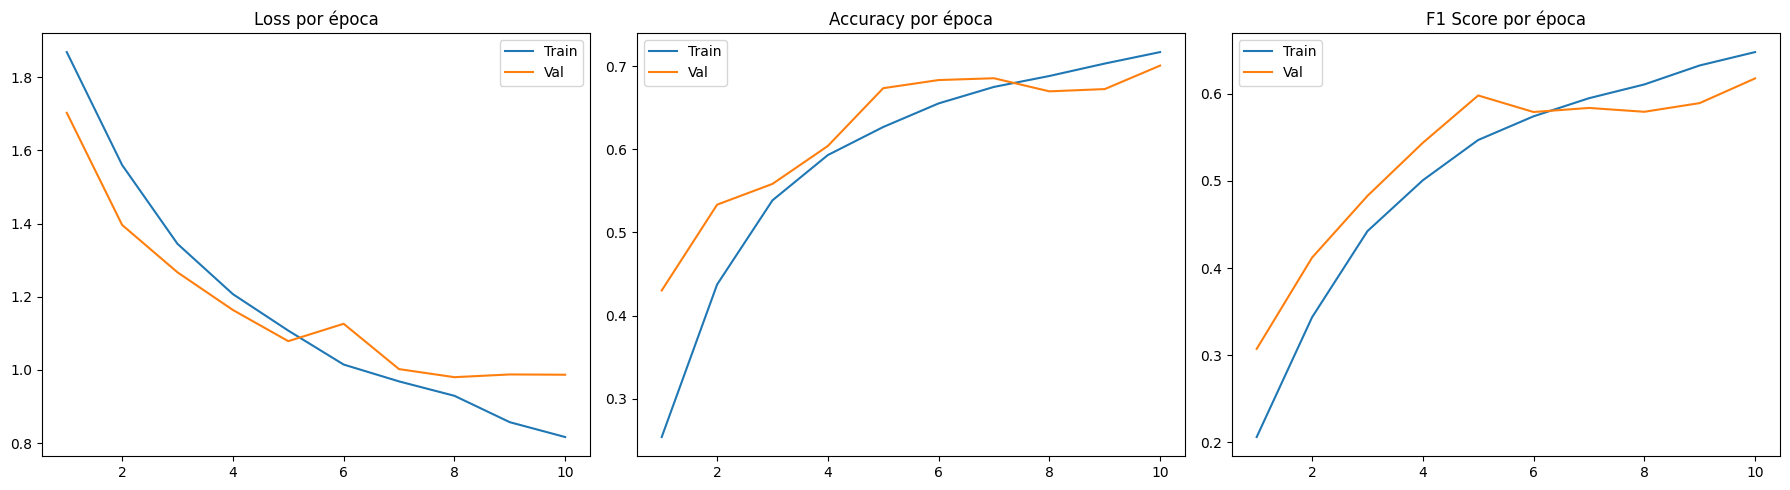

              precision    recall  f1-score   support

     alegria       0.92      0.83      0.87      1185
    disgusto       0.25      0.62      0.36       160
       enojo       0.59      0.69      0.64       162
       miedo       0.42      0.55      0.48        74
    seriedad       0.71      0.73      0.72       680
    sorpresa       0.76      0.72      0.74       329
    tristeza       0.79      0.51      0.62       478

    accuracy                           0.72      3068
   macro avg       0.63      0.66      0.63      3068
weighted avg       0.77      0.72      0.74      3068



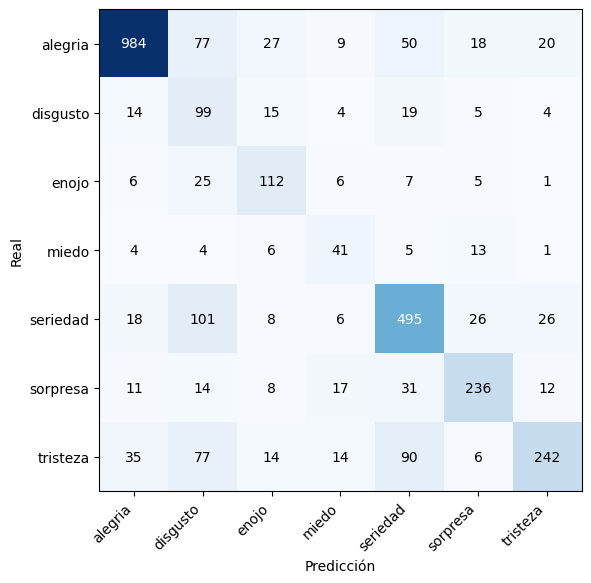

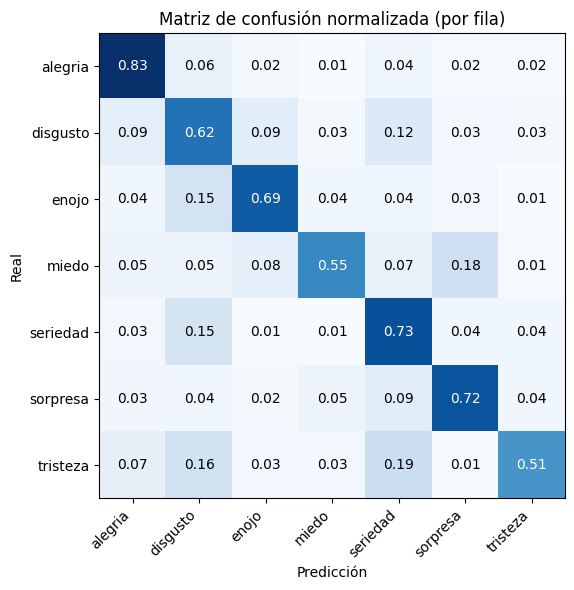

In [33]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import torch

# Curvas de entrenamiento
ep_range = range(1, EPOCHS + 1)
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(ep_range, history["train_loss"], label="Train")
plt.plot(ep_range, history["val_loss"], label="Val")
plt.title("Loss por época"); plt.legend()

plt.subplot(1, 3, 2)
plt.plot(ep_range, history["train_acc"], label="Train")
plt.plot(ep_range, history["val_acc"], label="Val")
plt.title("Accuracy por época"); plt.legend()

plt.subplot(1, 3, 3)
plt.plot(ep_range, history["train_f1"], label="Train")
plt.plot(ep_range, history["val_f1"], label="Val")
plt.title("F1 Score por época"); plt.legend()

plt.tight_layout(); plt.show()

# Inferencia sobre el set de test
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for x, y in test_dl:
        x, y = x.to(DEVICE), y.to(DEVICE)
        outputs = model(x)
        preds = outputs.argmax(dim=1)
        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# 2 · Reporte de clasificación
# Usar las clases definidas en el dataset de test
print(classification_report(
    y_true,
    y_pred,
    target_names=test_dl.dataset.classes
))

# 3 · Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cm, cmap="Blues")

n = len(test_dl.dataset.classes)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(test_dl.dataset.classes, rotation=45, ha="right")
ax.set_yticklabels(test_dl.dataset.classes)

# Anotar valores en cada celda
for i in range(n):
    for j in range(n):
        color = "white" if cm[i, j] > cm.max()/2 else "black"
        ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()


# 4 · Matriz de confusión normalizada (por fila)
cm = confusion_matrix(y_true, y_pred, normalize='true')
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(test_dl.dataset.classes, rotation=45, ha="right")
ax.set_yticklabels(test_dl.dataset.classes)

# Anotar valores normalizados
for i in range(n):
    for j in range(n):
        color = "white" if cm[i, j] > 0.5 else "black"
        ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", color=color)

ax.set_title("Matriz de confusión normalizada (por fila)")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

---
## Conclusiones y comentarios finales

El modelo alcanzó una precisión de validación de aproximadamente **70 %** y un _F1-score_ macro cercano a **62 %**, superando el nivel de azar en la clasificación de las siete expresiones faciales.  

**Aspectos destacados**  
- El preprocesamiento uniforme permitió entrenar de manera estable.  
- La arquitectura con cuatro bloques convolucionales y dos capas densas intermedias resultó suficiente para distinguir las emociones.
- Anterior a eso, se habia utilizado una sola capa densa y el modelo no superaba el 30% en la precisión de validación

**Limitaciones identificadas**  
- Clases con menor cantidad de ejemplos (por ejemplo “enojo” o “miedo”) presentan bajo _recall_.  
- Se observaron indicios de _overfitting_ a partir de la época 10.
- En un principio se entrenó a 30 épocas pero se limitó a 10 para evitar el sobreajuste. Se podria implementar una mejora de este codigo implementando un _early stopping_

A continuación, se muestran predicciones sobre imágenes nuevas ubicadas en `Fotos_de_prueba`:

```python
show_new(img_path)

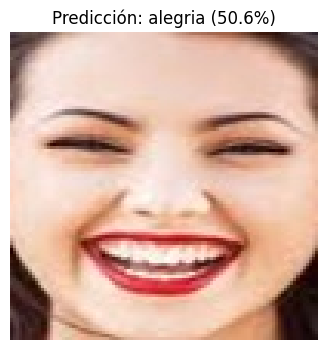

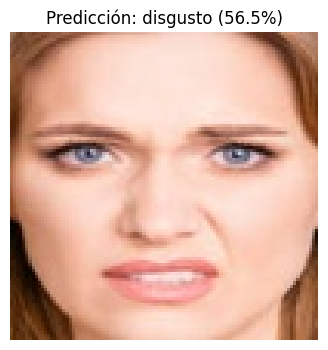

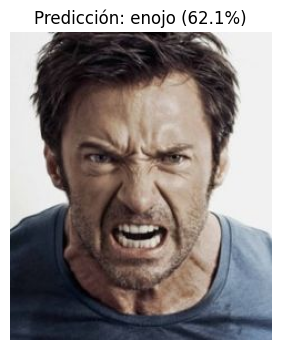

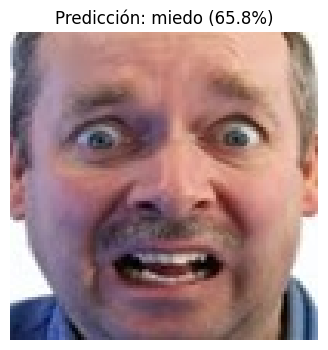

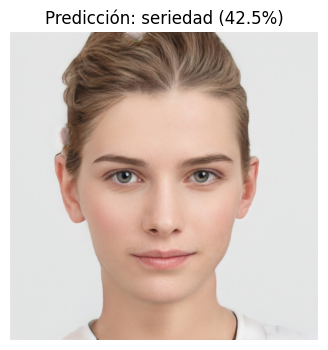

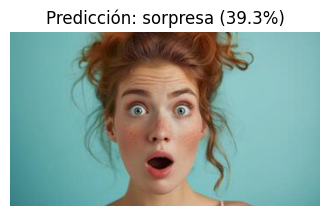

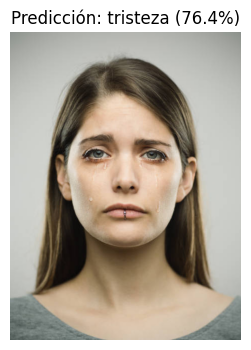

In [70]:
import os
import glob
import torch
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T

# Dispositivo y carga del mejor modelo entrenado
device = DEVICE
model.to(device)

# Lista de nombres de clases según ImageFolder
class_names = dataset.classes

# Preprocesamiento idéntico a validación
tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist())
])

def show_new(img_path):
    img_orig = Image.open(img_path).convert("RGB")
    x = tfm(img_orig).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x)
        pred = logits.argmax(dim=1).item()
        prob = torch.softmax(logits, dim=1)[0, pred].item()
    plt.figure(figsize=(4, 4))
    plt.imshow(img_orig)
    plt.axis("off")
    plt.title(f"Predicción: {class_names[pred]} ({prob:.1%})")
    plt.show()

# Ejecución sobre todas las imágenes de la carpeta de prueba
for img_path in glob.glob(os.path.join(PRUEBA_DIR, "*.*")):
    show_new(img_path)
